# Diagnóstico de una regresión lineal para ozono en la estación MER

**Fuente:** datos horarios de contaminantes del SIMAT, archivo `contaminantes_2026.csv`.  
**Estación:** MER (Merced).  
**Variable respuesta:** concentración horaria de ozono (`O3`).  
**Variables explicativas:** `NO`, `NO2`, `NOX` y `CO`.

El objetivo es ajustar una regresión lineal múltiple y revisar sus supuestos mediante el factor de inflación de la varianza (VIF), la prueba de Breusch–Pagan, el estadístico de Durbin–Watson, gráficas de residuos y un QQ-plot.

Todas las estimaciones y pruebas se realizarán con las mismas horas que tengan disponibles las cinco mediciones.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from pathlib import Path
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

## 1. Lectura y revisión inicial

El CSV comienza con líneas de metadatos del SIMAT antes de la fila que contiene los nombres de columnas. Para evitar depender de un número fijo de líneas, localizaremos automáticamente el encabezado que comienza con `date,id_station,id_parameter`.

El archivo está en formato **largo**: cada combinación de fecha, estación y contaminante ocupa una fila.

In [2]:
ruta = Path("contaminantes_2026.csv")

if not ruta.exists():
    raise FileNotFoundError(
        f"No se encontró {ruta.name} en el directorio actual. "
        "En Colab, verifica que esté en la carpeta mostrada por el panel de archivos."
    )

# Localizamos la fila del encabezado real sin suponer cuántos
# renglones de metadatos tiene el archivo.
with ruta.open("r", encoding="utf-8-sig") as archivo:
    for numero_linea, linea in enumerate(archivo):
        encabezado = linea.strip().replace('"', "").replace(" ", "").lower()
        if encabezado.startswith("date,id_station,id_parameter,"):
            filas_previas = numero_linea
            break
    else:
        raise ValueError(
            "No se encontró el encabezado "
            "'date,id_station,id_parameter' en el CSV."
        )

df_original = pd.read_csv(
    ruta,
    skiprows=filas_previas,
    encoding="utf-8-sig",
    low_memory=False
)

df_original.columns = df_original.columns.str.strip()

print("Filas de metadatos omitidas:", filas_previas)
print("Dimensiones del archivo:", df_original.shape)
print("Columnas:", df_original.columns.tolist())
display(df_original.head())

Filas de metadatos omitidas: 9
Dimensiones del archivo: (433296, 5)
Columnas: ['date', 'id_station', 'id_parameter', 'valor', 'unit']


,date,id_station,id_parameter,valor,unit
0,2026-01-01 00:00:00,ACO,CO,NaN,NaN
1,2026-01-01 00:00:00,ACO,NO,NaN,NaN
2,2026-01-01 00:00:00,ACO,NO2,NaN,NaN
3,2026-01-01 00:00:00,ACO,NOX,NaN,NaN
4,2026-01-01 00:00:00,ACO,O3,NaN,NaN


## 2. Selección de la estación y preparación de los datos

Conservamos únicamente la estación `MER` y los cinco contaminantes necesarios. Convertimos la fecha a un formato temporal y las mediciones a números; los valores vacíos o no numéricos se registran como faltantes.

Después transformamos los datos a formato **ancho**: una fila representa una hora y las columnas representan `O3`, `NO`, `NO2`, `NOX` y `CO`. Finalmente conservamos solo las horas completas. No rellenamos los valores ausentes porque hacerlo modificaría artificialmente las relaciones que queremos diagnosticar.

In [3]:
variables = ["O3", "NO", "NO2", "NOX", "CO"]
predictores = ["NO", "NO2", "NOX", "CO"]
estacion = "MER"

df = df_original.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["id_station"] = df["id_station"].astype(str).str.strip()
df["id_parameter"] = df["id_parameter"].astype(str).str.strip()
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

mer_largo = df.loc[
    (df["id_station"] == estacion)
    & (df["id_parameter"].isin(variables)),
    ["date", "id_parameter", "valor", "unit"]
].copy()

if mer_largo.empty:
    raise ValueError("No se encontraron registros para la estación MER.")

print("Unidades registradas por contaminante:")
display(
    mer_largo.groupby("id_parameter")["unit"]
    .agg(lambda serie: sorted(serie.dropna().astype(str).unique()))
    .rename("unidades")
    .to_frame()
)

mer = mer_largo.pivot_table(
    index="date",
    columns="id_parameter",
    values="valor",
    aggfunc="first"
).sort_index()

faltantes = [variable for variable in variables if variable not in mer.columns]

if faltantes:
    raise ValueError(
        f"En MER no hay mediciones disponibles para: {faltantes}"
    )

print("Horas con dato en cada variable:")
display(mer[variables].count().rename("horas disponibles").to_frame())

datos = mer[variables].dropna().copy()

if len(datos) <= len(predictores) + 1:
    raise ValueError("No hay suficientes horas completas para ajustar el modelo.")

print(f"Horas completas utilizadas: {len(datos):,}")
print(f"Primera observación: {datos.index.min()}")
print(f"Última observación: {datos.index.max()}")

display(datos.head())

Unidades registradas por contaminante:


,unidades
id_parameter,
CO,[15.0]
NO,[1.0]
NO2,[1.0]
NOX,[1.0]
O3,[1.0]


Horas con dato en cada variable:


,horas disponibles
id_parameter,
O3,1291
NO,1339
NO2,1333
NOX,1339
CO,1342


Horas completas utilizadas: 1,283
Primera observación: 2026-01-01 00:00:00
Última observación: 2026-02-28 22:00:00


id_parameter,O3,NO,NO2,NOX,CO
date,,,,,
2026-01-01 00:00:00,8.0,7.0,41.0,47.0,1.25
2026-01-01 01:00:00,4.0,13.0,45.0,58.0,1.51
2026-01-01 02:00:00,4.0,27.0,48.0,76.0,1.83
2026-01-01 03:00:00,4.0,35.0,44.0,79.0,1.63
2026-01-01 04:00:00,5.0,12.0,44.0,56.0,1.42


## 3. Regresión lineal múltiple

Ajustamos el siguiente modelo mediante mínimos cuadrados ordinarios:

\[
O3_t = \beta_0+\beta_1 NO_t+\beta_2 NO2_t+
       \beta_3 NOX_t+\beta_4 CO_t+\varepsilon_t.
\]

El coeficiente de cada predictor representa su asociación estimada con `O3` al mantener constantes los otros tres predictores. Esta interpretación es **condicional y descriptiva**; por sí sola no demuestra causalidad.

Reportamos \(R^2\), \(R^2\) ajustado, coeficientes, intervalos de confianza y valores p convencionales del modelo.

In [6]:
X = sm.add_constant(datos[predictores])
y = datos["O3"]

modelo = sm.OLS(y, X).fit()

tabla_coeficientes = pd.DataFrame({
    "coeficiente": modelo.params,
    "error_estandar": modelo.bse,
    "estadistico_t": modelo.tvalues,
    "p_value": modelo.pvalues,
    "IC_95_inferior": modelo.conf_int()[0],
    "IC_95_superior": modelo.conf_int()[1]
})

print(f"Estación: {estacion}")
print(f"Observaciones: {int(modelo.nobs):,}")
print(f"R²: {modelo.rsquared:.4f}")
print(f"R² ajustado: {modelo.rsquared_adj:.4f}")

display(tabla_coeficientes.round(6))

Estación: MER
Observaciones: 1,283
R²: 0.2629
R² ajustado: 0.2606


,coeficiente,error_estandar,estadistico_t,p_value,IC_95_inferior,IC_95_superior
const,54.102220,2.133910,25.353567,0.000000,49.915869,58.288571
NO,0.233820,1.487292,0.157212,0.875102,-2.683982,3.151623
NO2,0.044640,1.488918,0.029981,0.976087,-2.876351,2.965631
NOX,-0.487954,1.488231,-0.327875,0.743060,-3.407598,2.431690
CO,3.884558,3.353774,1.158265,0.246972,-2.694950,10.464066


## 4. Multicolinealidad: factor de inflación de la varianza

El VIF de un predictor indica cuánto se incrementa la varianza estimada de su coeficiente debido a su relación lineal con los demás predictores. Como referencia práctica, valores superiores a 5 ameritan revisión y valores superiores a 10 indican una relación especialmente fuerte; estos umbrales no son reglas absolutas.

En este modelo es particularmente importante examinar `NO`, `NO2` y `NOX`, porque `NOX` está estrechamente relacionado con los otros dos.

In [7]:
tabla_vif = pd.DataFrame({
    "variable": predictores,
    "VIF": [
        variance_inflation_factor(X.to_numpy(), columna)
        for columna in range(1, X.shape[1])
    ]
})

display(tabla_vif.round(3))

print("Matriz de correlación entre predictores:")
display(datos[predictores].corr().round(3))

diferencia_nox = datos["NOX"] - datos["NO"] - datos["NO2"]

print(
    "Porcentaje de horas con NOX = NO + NO2 exactamente: "
    f"{(diferencia_nox == 0).mean():.1%}"
)
print(
    "Mediana de |NOX − NO − NO2|: "
    f"{diferencia_nox.abs().median():.3f}"
)

,variable,VIF
0,NO,10180.456
1,NO2,1194.141
2,NOX,14676.660
3,CO,5.964


Matriz de correlación entre predictores:


id_parameter,NO,NO2,NOX,CO
id_parameter,,,,
NO,1.000,0.471,0.968,0.806
NO2,0.471,1.000,0.678,0.756
NOX,0.968,0.678,1.000,0.888
CO,0.806,0.756,0.888,1.000


Porcentaje de horas con NOX = NO + NO2 exactamente: 73.6%
Mediana de |NOX − NO − NO2|: 0.000


## 5. Homocedasticidad: residuos frente a predichos y Breusch–Pagan

Un supuesto habitual de la inferencia OLS convencional es que la varianza del error sea aproximadamente constante. Graficamos los residuos contra los valores predichos: una dispersión que se ensancha o estrecha sistemáticamente sugeriría heterocedasticidad.

La prueba de Breusch–Pagan contrasta la hipótesis nula de varianza constante. Con un nivel de significancia de 0.05, un valor p menor que 0.05 constituye evidencia contra esa hipótesis.

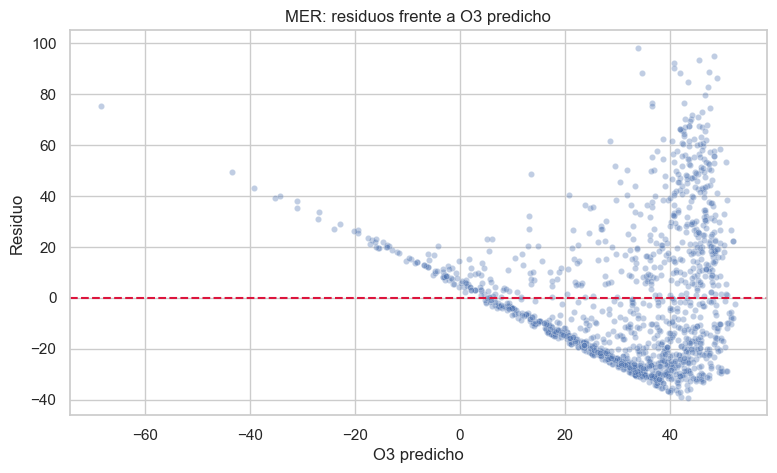

Breusch–Pagan, estadístico LM: 76.080
Breusch–Pagan, valor p (LM): 1.1775e-15
Breusch–Pagan, valor p (F): 4.22268e-16


In [8]:
diagnostico = pd.DataFrame(
    {
        "O3_observado": y,
        "O3_predicho": modelo.fittedvalues,
        "residuo": modelo.resid
    },
    index=datos.index
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.scatterplot(
    data=diagnostico,
    x="O3_predicho",
    y="residuo",
    alpha=0.35,
    s=20,
    ax=ax
)

ax.axhline(0, color="crimson", linestyle="--", linewidth=1.5)
ax.set(
    title="MER: residuos frente a O3 predicho",
    xlabel="O3 predicho",
    ylabel="Residuo"
)

plt.show()

bp_lm, bp_p, bp_f, bp_f_p = het_breuschpagan(
    modelo.resid,
    modelo.model.exog
)

print(f"Breusch–Pagan, estadístico LM: {bp_lm:.3f}")
print(f"Breusch–Pagan, valor p (LM): {bp_p:.6g}")
print(f"Breusch–Pagan, valor p (F): {bp_f_p:.6g}")

## 6. Dependencia temporal y patrón por hora del día

Al tratarse de datos horarios, observaciones cercanas en el tiempo podrían tener errores relacionados. Graficamos los residuos ordenados cronológicamente y calculamos su promedio para cada hora del día.

El estadístico de Durbin–Watson toma valores entre 0 y 4: un valor cercano a 2 es compatible con ausencia de autocorrelación de primer orden; valores menores que 2 sugieren autocorrelación positiva. Lo interpretamos junto con la gráfica, especialmente porque podrían faltar algunas horas en la muestra completa.

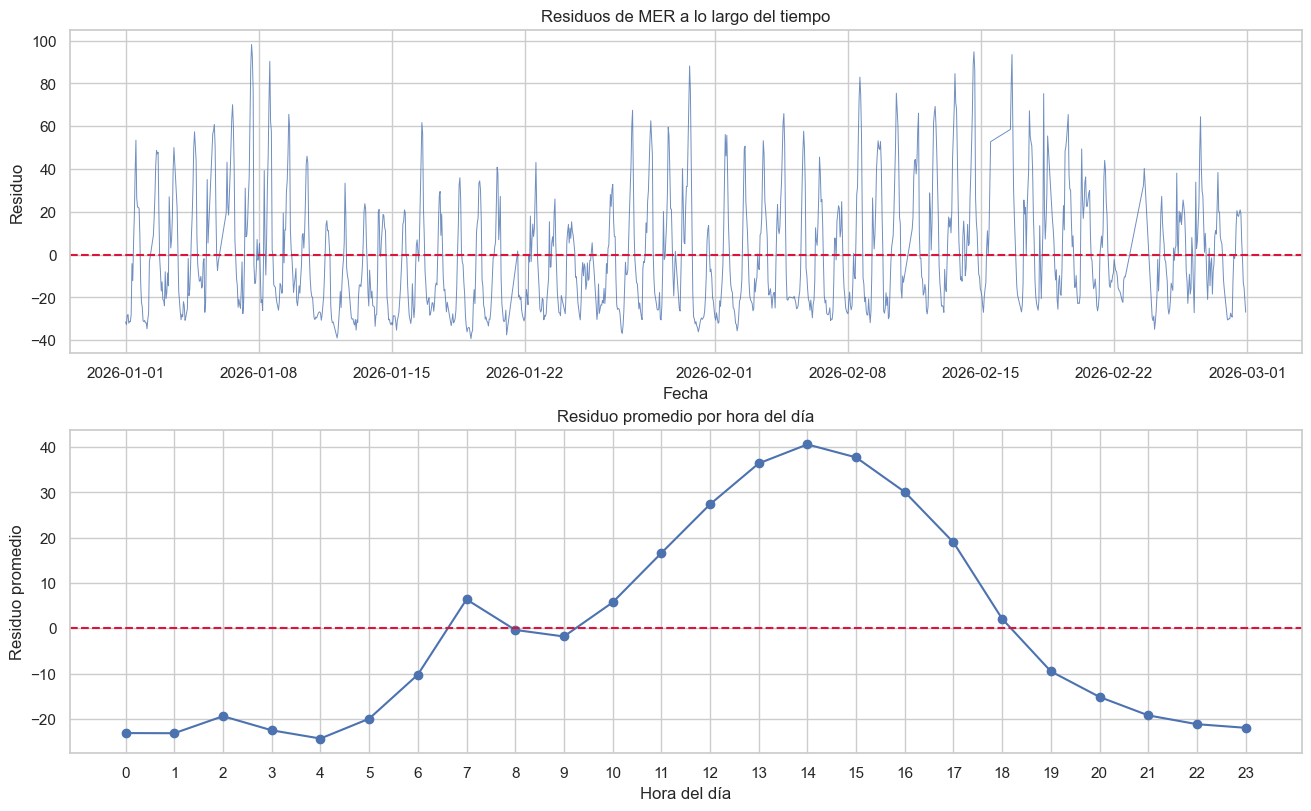

Estadístico Durbin–Watson: 0.2302


,residuo_promedio
hora_del_dia,
0,-23.145
1,-23.177
2,-19.416
3,-22.532
4,-24.354
5,-19.977
6,-10.251
7,6.371
8,-0.368


In [9]:
diagnostico["hora_del_dia"] = diagnostico.index.hour

promedio_por_hora = diagnostico.groupby("hora_del_dia")["residuo"].mean()

fig, ejes = plt.subplots(
    2, 1, figsize=(13, 8), constrained_layout=True
)

ejes[0].plot(
    diagnostico.index,
    diagnostico["residuo"],
    linewidth=0.7,
    alpha=0.8
)
ejes[0].axhline(0, color="crimson", linestyle="--")
ejes[0].set(
    title="Residuos de MER a lo largo del tiempo",
    xlabel="Fecha",
    ylabel="Residuo"
)

ejes[1].plot(
    promedio_por_hora.index,
    promedio_por_hora.values,
    marker="o"
)
ejes[1].axhline(0, color="crimson", linestyle="--")
ejes[1].set(
    title="Residuo promedio por hora del día",
    xlabel="Hora del día",
    ylabel="Residuo promedio",
    xticks=range(24)
)

plt.show()

dw = durbin_watson(modelo.resid)

print(f"Estadístico Durbin–Watson: {dw:.4f}")
display(
    promedio_por_hora
    .rename("residuo_promedio")
    .to_frame()
    .round(3)
)

## 7. Normalidad: QQ-plot de los residuos

El QQ-plot compara los cuantiles observados de los residuos con los cuantiles de una distribución normal. Si la distribución fuera aproximadamente normal, los puntos seguirían la recta de referencia. Desviaciones claras, sobre todo en las colas, sugieren falta de normalidad.

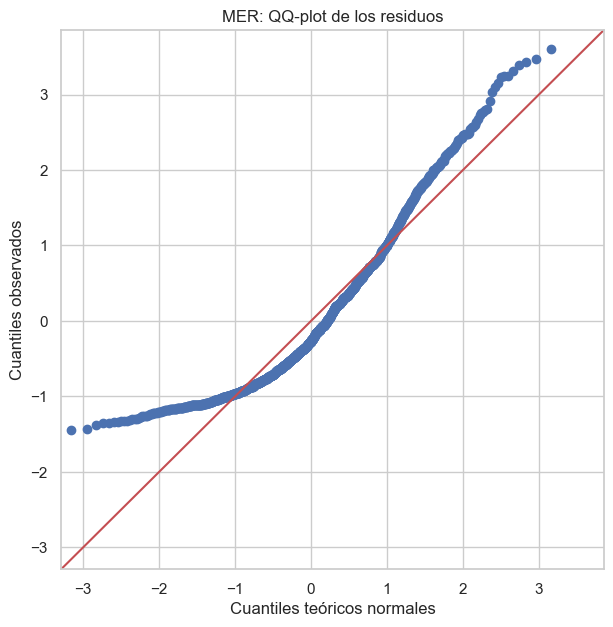

In [10]:
fig, ax = plt.subplots(figsize=(7, 7))

sm.qqplot(
    modelo.resid,
    line="45",
    fit=True,
    ax=ax
)

ax.set(
    title="MER: QQ-plot de los residuos",
    xlabel="Cuantiles teóricos normales",
    ylabel="Cuantiles observados"
)

plt.show()

## Conclusión

En la estación MER se analizaron **1,283 horas completas** de enero y febrero de 2026. La regresión de `O3` sobre `NO`, `NO2`, `NOX` y `CO` obtuvo un \(R^2=0.2629\): explica aproximadamente el **26.3 %** de la variación observada del ozono. Los diagnósticos muestran que varios supuestos no se cumplen. Breusch–Pagan indica **heterocedasticidad** (\(p=1.18\times10^{-15}\)); Durbin–Watson fue **0.2302**, compatible con una fuerte autocorrelación positiva; el promedio de los residuos cambia notablemente según la hora del día, y el QQ-plot muestra desviaciones de la normalidad. También existe **multicolinealidad extrema**: el VIF de `NO2` es **1,194** y, en el **73.6 %** de las horas, `NOX = NO + NO2` exactamente. Por ello, **no confiaría en el coeficiente individual de `NO2` (0.0446) ni interpretaría su valor p convencional (0.9761) como prueba de que no se relaciona con `O3`**. La redundancia entre predictores dificulta separar sus asociaciones individuales, mientras que la heterocedasticidad y la dependencia temporal afectan la validez de la inferencia convencional.